In [122]:
import pandas as pd
import numpy as np

In [15]:
'''Part 1'''
df_1 = pd.read_csv('Auto-1.txt', sep='\t')
df_1.info()
df_1.dropna()
df_1.head(11)

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 1 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    int64  
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   year          392 non-null    int64  
 7   origin        392 non-null    int64  
 8   name          392 non-null    object 
dtypes: float64(3), int64(5), object(1)
memory usage: 30.6+ KB


,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
1,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
2,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
3,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
4,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
5,17.0,8,302.0,140,3449,10.5,70,1,ford torino
6,15.0,8,429.0,198,4341,10.0,70,1,ford galaxie 500
7,14.0,8,454.0,220,4354,9.0,70,1,chevrolet impala
8,14.0,8,440.0,215,4312,8.5,70,1,plymouth fury iii
9,14.0,8,455.0,225,4425,10.0,70,1,pontiac catalina
10,15.0,8,390.0,190,3850,8.5,70,1,amc ambassador dpl


In [6]:
df_1.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592,1.576531
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737,0.805518
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000,1.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


In [7]:
df_1_removed = df_1.drop(range(10, 86), errors='ignore')
df_1_removed.head(11)

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
1,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
2,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
3,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
4,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
5,17.0,8,302.0,140,3449,10.5,70,1,ford torino
6,15.0,8,429.0,198,4341,10.0,70,1,ford galaxie 500
7,14.0,8,454.0,220,4354,9.0,70,1,chevrolet impala
8,14.0,8,440.0,215,4312,8.5,70,1,plymouth fury iii
9,14.0,8,455.0,225,4425,10.0,70,1,pontiac catalina
86,13.0,8,350.0,175,4100,13.0,73,1,buick century 350


In [8]:
df_1_removed.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
count,317.000000,317.000000,317.000000,317.000000,317.000000,317.000000,317.000000,317.000000
mean,24.368454,5.381703,187.753943,100.955836,2939.643533,15.718297,77.132492,1.599369
std,7.880898,1.658135,99.939488,35.895567,812.649629,2.693813,3.110026,0.819308
min,11.000000,3.000000,68.000000,46.000000,1649.000000,8.500000,70.000000,1.000000
25%,18.000000,4.000000,101.000000,75.000000,2215.000000,14.000000,75.000000,1.000000
50%,23.900000,4.000000,146.000000,90.000000,2795.000000,15.500000,77.000000,1.000000
75%,30.500000,6.000000,250.000000,115.000000,3520.000000,17.300000,80.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,4997.000000,24.800000,82.000000,3.000000


In [123]:
import seaborn as sns
import matplotlib.pyplot as plt

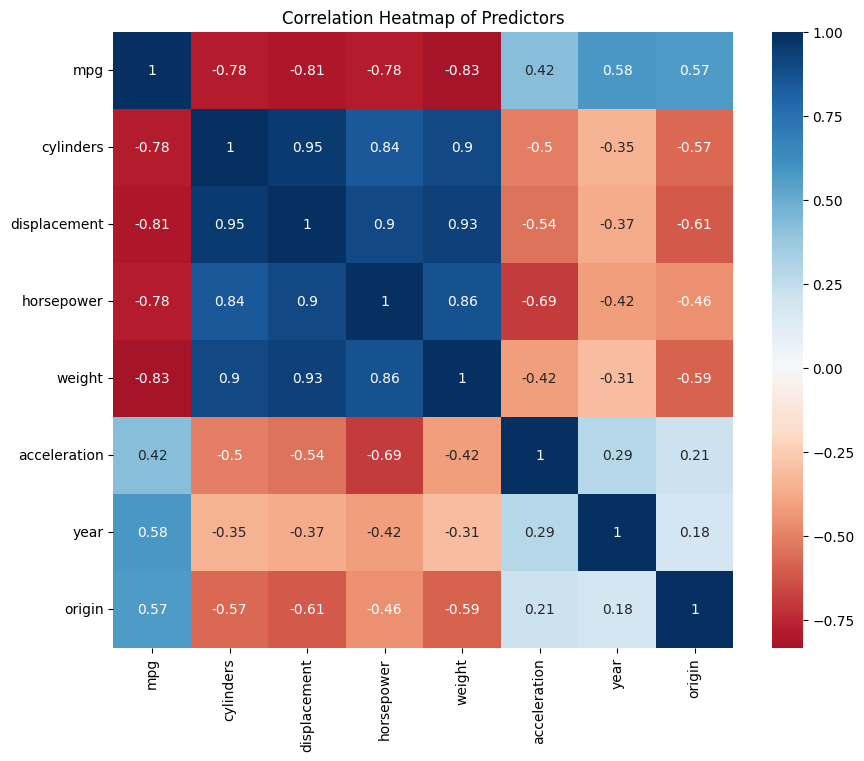

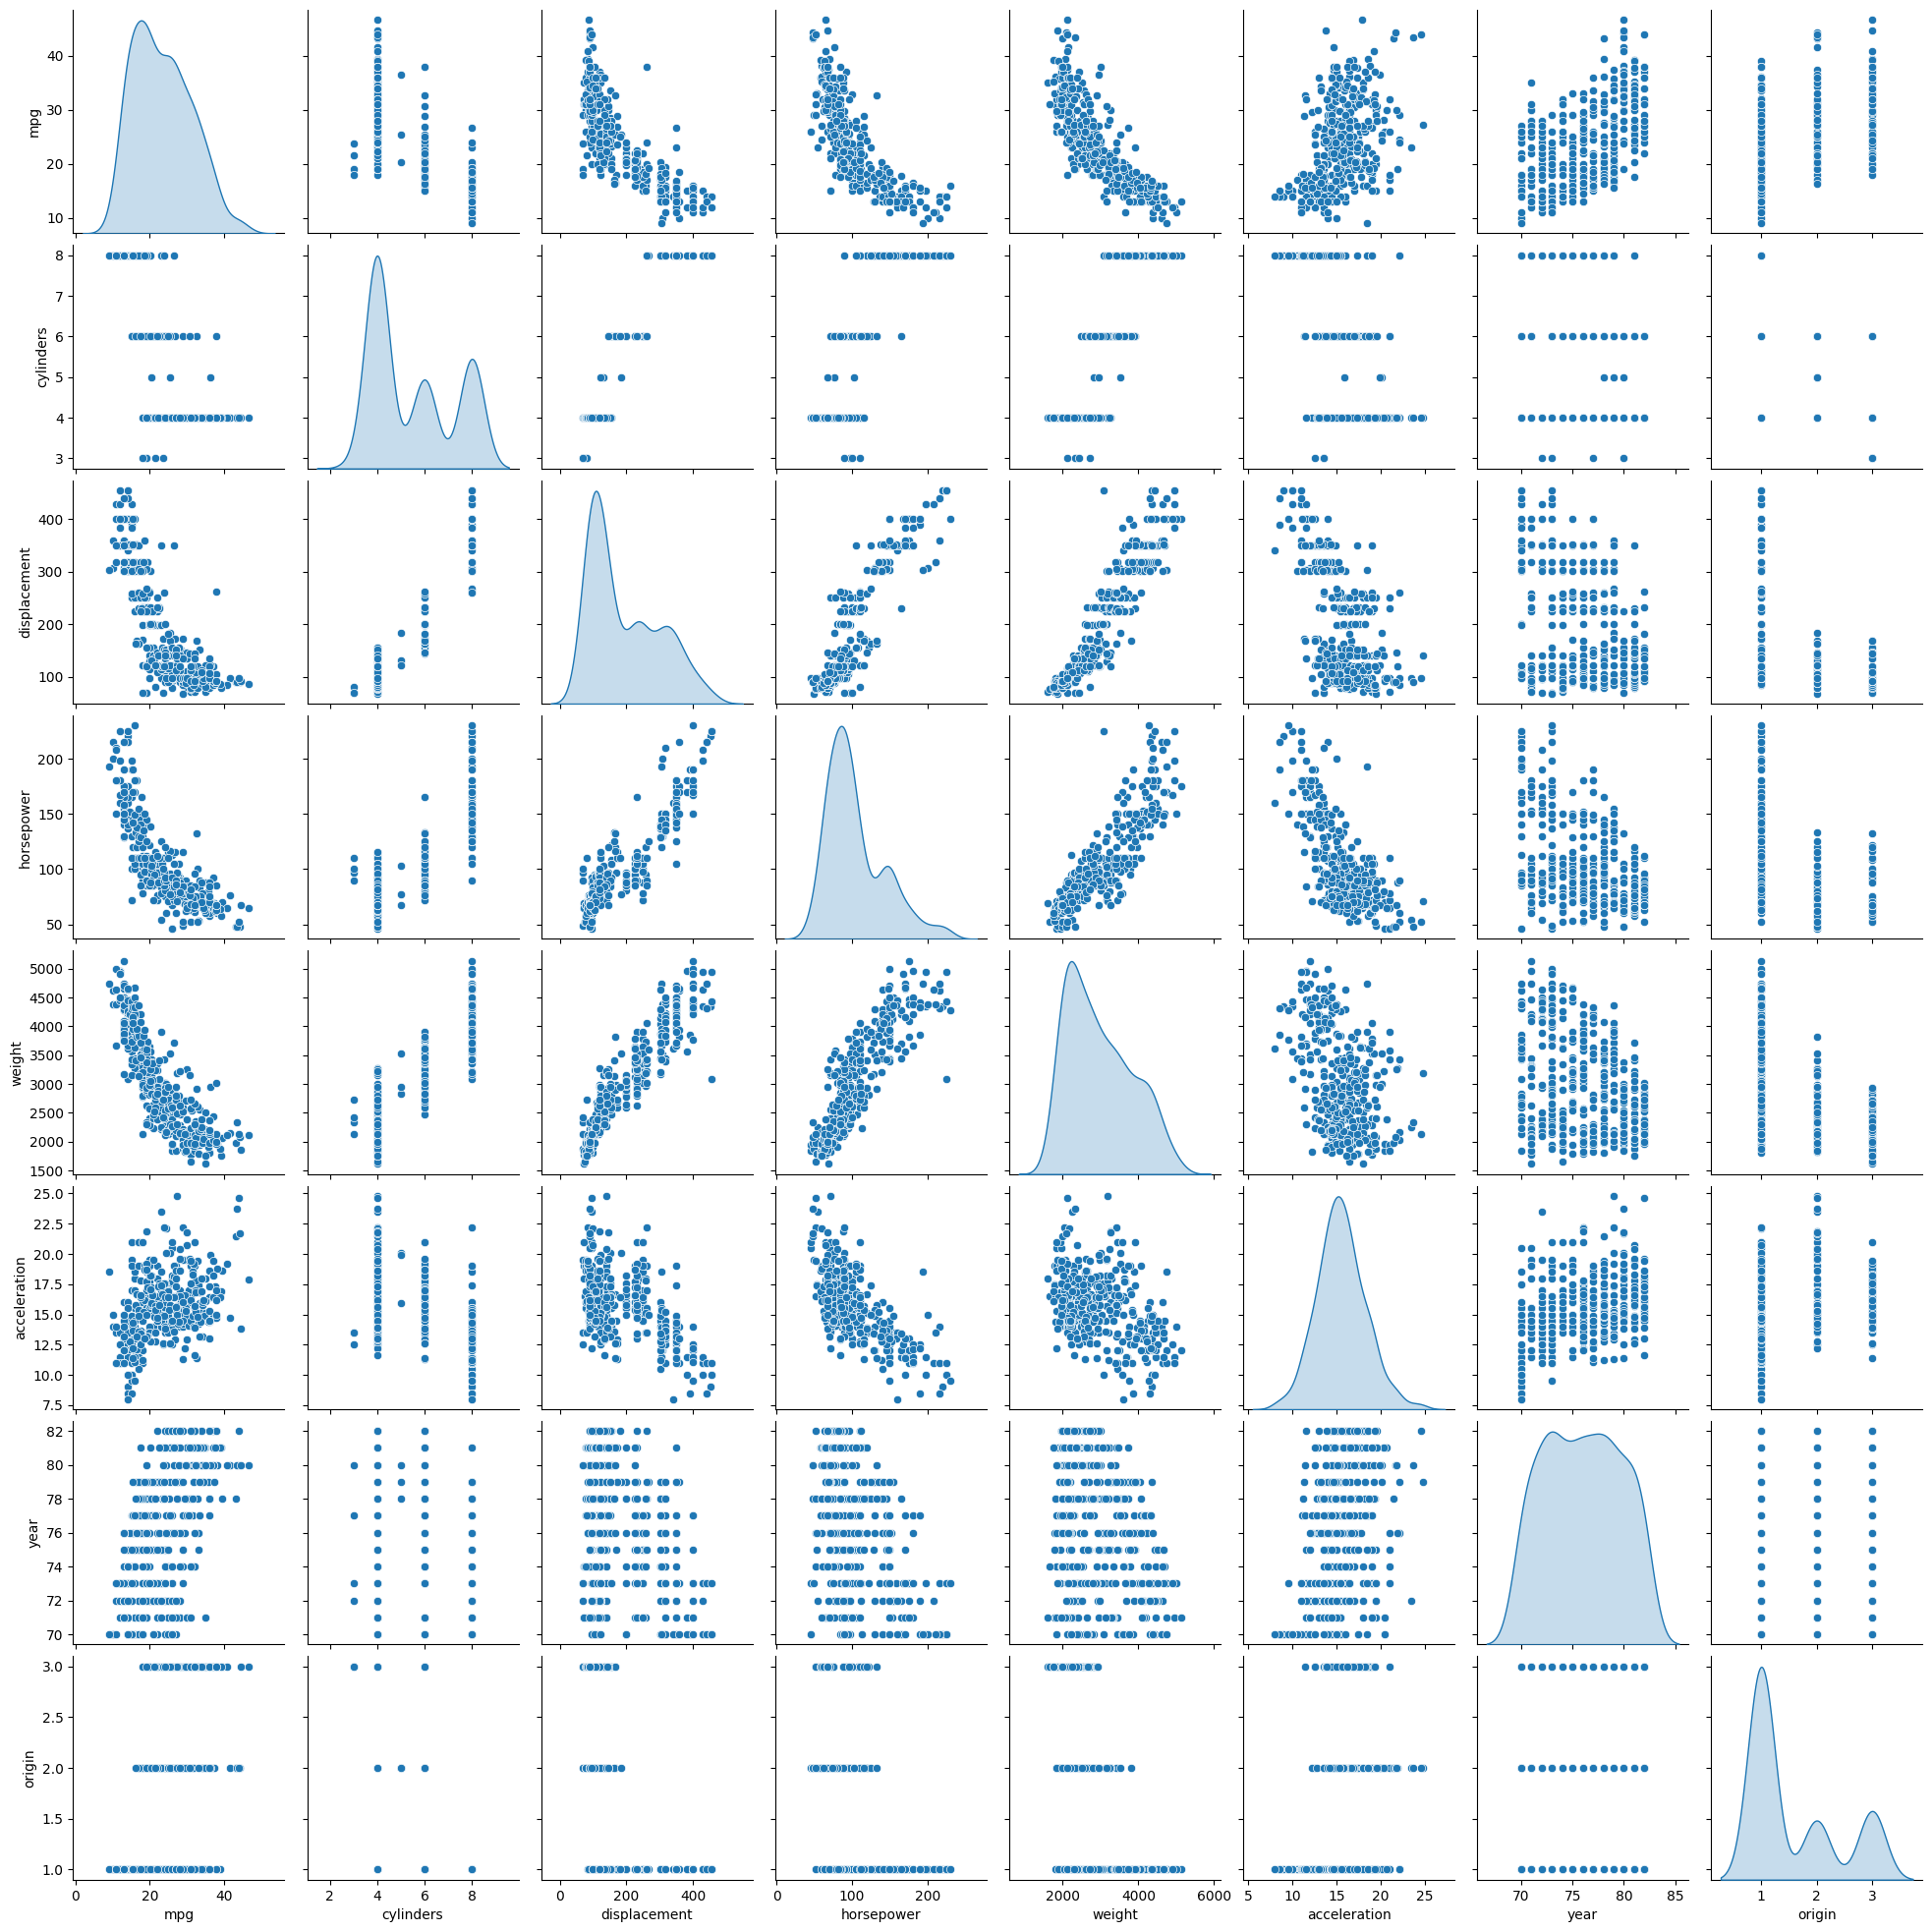

In [10]:
# 1. Correlation Heatmap
plt.figure(figsize=(10, 8))
corr = df_1.drop(columns=['name']).corr()
sns.heatmap(corr, annot=True, cmap='RdBu', center=0)
plt.title('Correlation Heatmap of Predictors')
plt.show()

# 2. Pairplot
cols_to_plot = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'year', 'origin']
sns.pairplot(df_1[cols_to_plot], diag_kind='kde')
plt.show()

In [12]:
import statsmodels.api as sm

In [13]:
# p-value
X = df_1.drop(columns=['mpg', 'name'])
y = df_1['mpg']

# Statsmodels requires an explicit intercept (constant) to be added
X = sm.add_constant(X)

# Fit the Ordinary Least Squares (OLS) model
model = sm.OLS(y, X).fit()

# View the results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     252.4
Date:                Fri, 20 Feb 2026   Prob (F-statistic):          2.04e-139
Time:                        20:14:29   Log-Likelihood:                -1023.5
No. Observations:                 392   AIC:                             2063.
Df Residuals:                     384   BIC:                             2095.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -17.2184      4.644     -3.707   

In [16]:
'''Part 2'''
df_2 = pd.read_csv('Boston-1.csv')
df_2.info()
df_2.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  506 non-null    int64  
 1   crim        506 non-null    float64
 2   zn          506 non-null    float64
 3   indus       506 non-null    float64
 4   chas        506 non-null    int64  
 5   nox         506 non-null    float64
 6   rm          506 non-null    float64
 7   age         506 non-null    float64
 8   dis         506 non-null    float64
 9   rad         506 non-null    int64  
 10  tax         506 non-null    int64  
 11  ptratio     506 non-null    float64
 12  black       506 non-null    float64
 13  lstat       506 non-null    float64
 14  medv        506 non-null    float64
dtypes: float64(11), int64(4)
memory usage: 59.4 KB


,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [51]:
df_2.describe()

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,253.500000,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,146.213884,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,1.000000,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,127.250000,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,253.500000,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,379.750000,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,506.000000,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


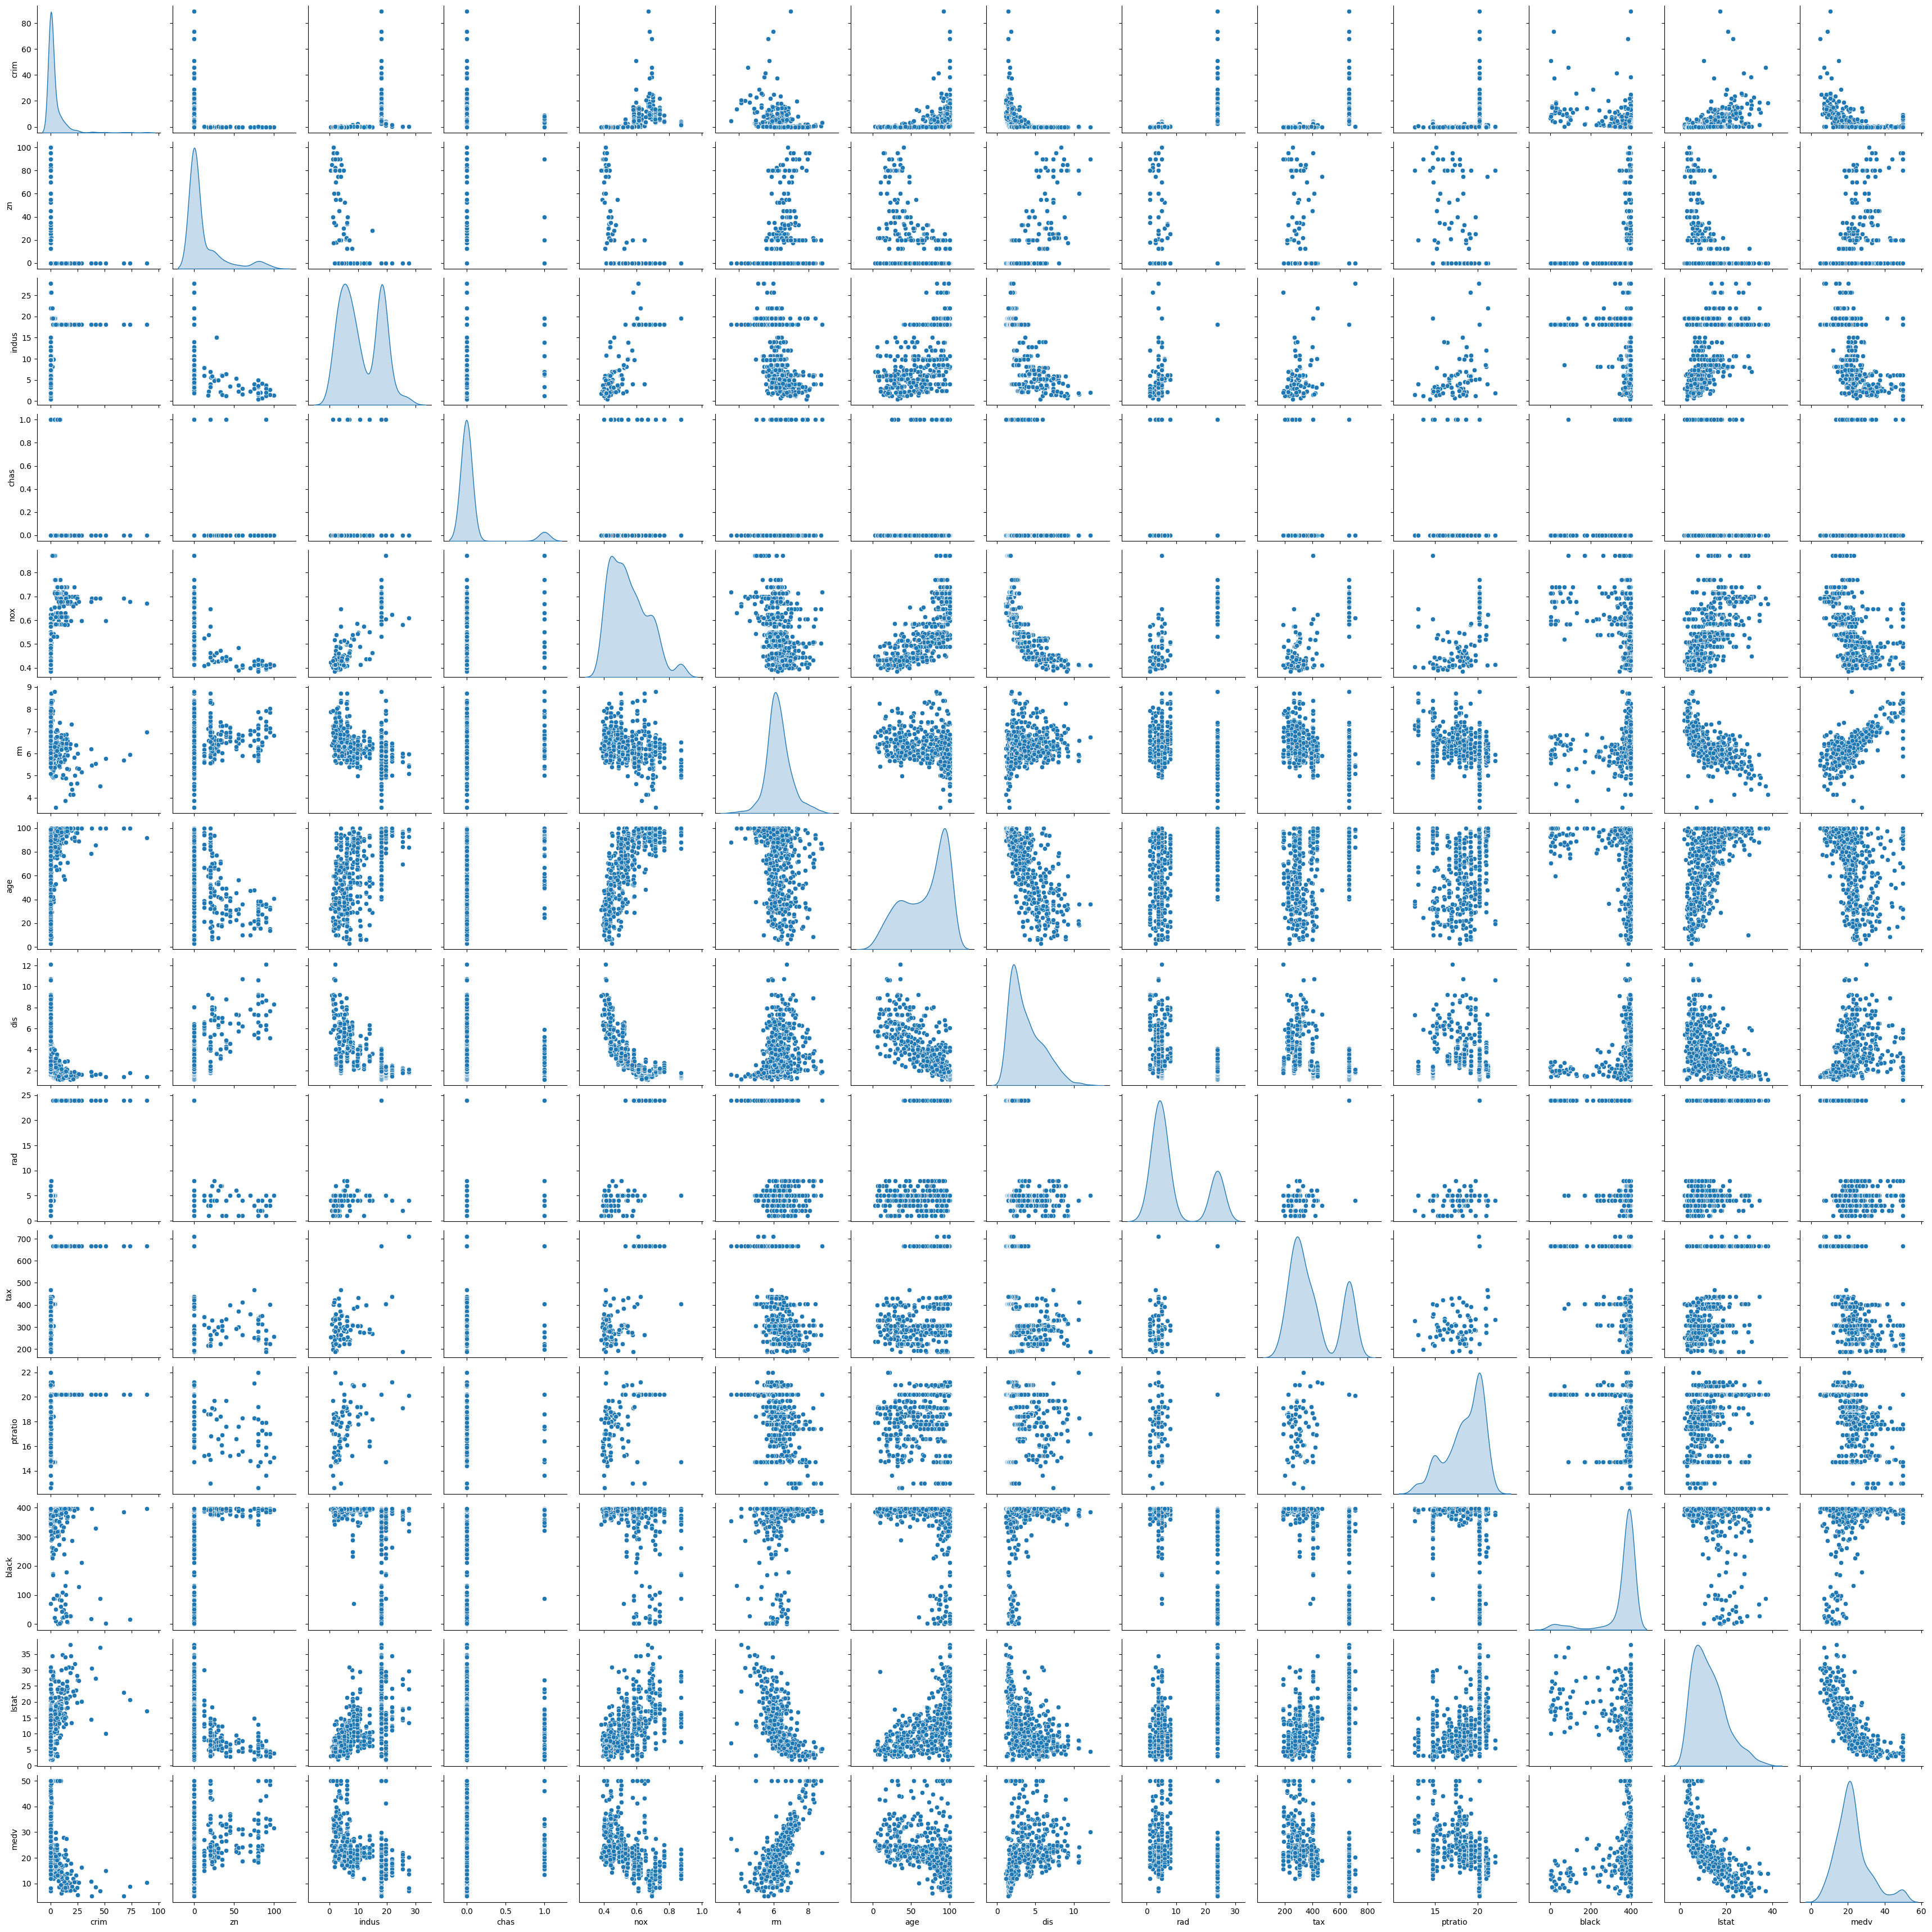

In [23]:
# Pairplot
cols_to_plot = df_2.drop(columns=['Unnamed: 0']).columns.to_list()
sns.pairplot(df_2[cols_to_plot], diag_kind='kde')
plt.show()

In [30]:
# p-value
X_2 = df_2.drop(columns=['crim', 'Unnamed: 0'])
y_2 = df_2['crim']

# Statsmodels requires an explicit intercept (constant) to be added
X_2 = sm.add_constant(X_2)

# Fit the Ordinary Least Squares (OLS) model
model_2 = sm.OLS(y_2, X_2).fit()

# View the results
print(model_2.summary())

                            OLS Regression Results                            
Dep. Variable:                   crim   R-squared:                       0.454
Model:                            OLS   Adj. R-squared:                  0.440
Method:                 Least Squares   F-statistic:                     31.47
Date:                Fri, 20 Feb 2026   Prob (F-statistic):           1.57e-56
Time:                        21:31:28   Log-Likelihood:                -1653.3
No. Observations:                 506   AIC:                             3335.
Df Residuals:                     492   BIC:                             3394.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         17.0332      7.235      2.354      0.0

In [39]:
df_2[['crim', 'tax', 'ptratio']].describe()

,crim,tax,ptratio
count,506.000000,506.000000,506.000000
mean,3.613524,408.237154,18.455534
std,8.601545,168.537116,2.164946
min,0.006320,187.000000,12.600000
25%,0.082045,279.000000,17.400000
50%,0.256510,330.000000,19.050000
75%,3.677083,666.000000,20.200000
max,88.976200,711.000000,22.000000


In [52]:
df_2[df_2['chas'] == 1].count()

,0
Unnamed: 0,35
crim,35
zn,35
indus,35
chas,35
nox,35
rm,35
age,35
dis,35
rad,35


In [53]:
df_2[df_2['chas'] == 1].describe()


,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
count,35.000000,35.000000,35.000000,35.000000,35.0,35.000000,35.000000,35.00000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000
mean,251.485714,1.851670,7.714286,12.719143,1.0,0.593426,6.519600,77.50000,3.029709,9.314286,386.257143,17.491429,372.997429,11.241714,28.440000
std,73.880815,2.494072,18.800143,5.957623,0.0,0.144736,0.876416,22.02134,1.254728,8.248962,165.012004,2.081766,53.382820,6.686651,11.816643
min,143.000000,0.015010,0.000000,1.210000,1.0,0.401000,5.012000,24.80000,1.129600,1.000000,198.000000,13.600000,88.010000,1.920000,13.400000
25%,210.500000,0.125060,0.000000,6.410000,1.0,0.489000,5.935500,60.30000,1.904700,4.000000,276.000000,15.650000,376.200000,5.395000,21.100000
50%,223.000000,0.447910,0.000000,13.890000,1.0,0.550000,6.250000,88.50000,3.048000,5.000000,307.000000,17.600000,390.770000,10.500000,23.300000
75%,283.500000,3.397665,0.000000,18.100000,1.0,0.693000,6.915000,93.20000,3.897300,8.000000,403.000000,18.600000,393.595000,15.070000,33.150000
max,373.000000,8.982960,90.000000,19.580000,1.0,0.871000,8.780000,100.00000,5.885000,24.000000,666.000000,20.200000,396.900000,26.820000,50.000000


In [50]:
df_2['ptratio'].median()

19.05

In [54]:
df_2[df_2['medv'] == df_2['medv'].min()]

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
398,399,38.3518,0.0,18.1,0,0.693,5.453,100.0,1.4896,24,666,20.2,396.90,30.59,5.0
405,406,67.9208,0.0,18.1,0,0.693,5.683,100.0,1.4254,24,666,20.2,384.97,22.98,5.0


In [62]:
df_2[df_2['rm'] > 7].shape[0]

64

In [63]:
df_2[df_2['rm'] > 8].shape[0]

13

In [65]:
df_2[df_2['rm'] > 8].drop(columns='Unnamed: 0').describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
count,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000
mean,0.718795,13.615385,7.078462,0.153846,0.539238,8.348538,71.538462,3.430192,7.461538,325.076923,16.361538,385.210769,4.310000,44.200000
std,0.901640,26.298094,5.392767,0.375534,0.092352,0.251261,24.608723,1.883955,5.332532,110.971063,2.410580,10.529359,1.373566,8.092383
min,0.020090,0.000000,2.680000,0.000000,0.416100,8.034000,8.400000,1.801000,2.000000,224.000000,13.000000,354.550000,2.470000,21.900000
25%,0.331470,0.000000,3.970000,0.000000,0.504000,8.247000,70.400000,2.288500,5.000000,264.000000,14.700000,384.540000,3.320000,41.700000
50%,0.520140,0.000000,6.200000,0.000000,0.507000,8.297000,78.300000,2.894400,7.000000,307.000000,17.400000,386.860000,4.140000,48.300000
75%,0.578340,20.000000,6.200000,0.000000,0.605000,8.398000,86.500000,3.651900,8.000000,307.000000,17.400000,389.700000,5.120000,50.000000
max,3.474280,95.000000,19.580000,1.000000,0.718000,8.780000,93.900000,8.906700,24.000000,666.000000,20.200000,396.900000,7.440000,50.000000


In [66]:
'''part 3'''

df_3 = pd.read_csv('Carseats-4.csv')
df_3.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


In [69]:
df_3['US_num'] = df_3['US'].map({'Yes': 1, 'No': 0})
df_3['Urban_num'] = df_3['Urban'].map({'Yes': 1, 'No': 0})
df_3.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,US_num,Urban_num
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes,1,1
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes,1,1
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes,1,1
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes,1,1
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No,0,1


In [71]:
import statsmodels.api as sm

# Define the dependent variable
y_3 = df_3['Sales']

# Define the independent variables
X_3_cols = ['Price', 'Advertising', 'Urban_num', 'US_num']
X_3 = df_3[X_3_cols]

# Add a constant to the independent variables (required for Statsmodels OLS)
X_3 = sm.add_constant(X_3)

# Fit the multiple regression model
model_3 = sm.OLS(y_3, X_3).fit()

# Print the model summary
print(model_3.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.282
Model:                            OLS   Adj. R-squared:                  0.275
Method:                 Least Squares   F-statistic:                     38.77
Date:                Fri, 20 Feb 2026   Prob (F-statistic):           2.21e-27
Time:                        22:44:10   Log-Likelihood:                -916.11
No. Observations:                 400   AIC:                             1842.
Df Residuals:                     395   BIC:                             1862.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          13.0113      0.633     20.544      

In [100]:
# Create a new DataFrame for the store's data
new_store_data = pd.DataFrame({
    'const': [1],  # Constant term for the intercept
    'Price': [120],
    'Advertising': [10], # 10k
    'Urban_num': [1],  # Urban=Yes
    'US_num': [1]      # US=Yes
})

# Predict the sales
predicted_sales = model_3.predict(new_store_data)[0]

print(f"Predicted Sales: {predicted_sales:.2f}")

# standerd deviation
rmse = np.sqrt(model_3.mse_resid)
print(f"RMSE: {rmse:f}")
print(f"68%: ({(predicted_sales - rmse):.2f}, {(predicted_sales + rmse):.2f})")
print(f"95%: ({(predicted_sales - rmse * 2):.2f}, {(predicted_sales + rmse * 2):.2f})")



Predicted Sales: 7.68
RMSE: 2.405189
68%: (5.28, 10.09)
95%: (2.87, 12.49)


In [101]:
from scipy.stats import norm

In [103]:
prob_greater_12 = norm.sf(12, loc=predicted_sales, scale=rmse)
print(f"Probability that Sales > 12,000: {prob_greater_12:.2%}")

Probability that Sales > 12,000: 3.63%


In [104]:
prob_below_10 = norm.cdf(10, loc=predicted_sales, scale=rmse)
prob_below_6 = norm.cdf(6, loc=predicted_sales, scale=rmse)
prob_between = prob_below_10 - prob_below_6
print(f"Probability of Sales between 6,000 and 10,000: {prob_between:.2%}")

Probability of Sales between 6,000 and 10,000: 59.02%


In [105]:
# Define the dependent variable
y_3 = df_3['Sales']

# Define the independent variables
X_3_cols = ['Price', 'Advertising']
X_3 = df_3[X_3_cols]

# Add a constant to the independent variables (required for Statsmodels OLS)
X_3 = sm.add_constant(X_3)

# Fit the multiple regression model
model_3_pa = sm.OLS(y_3, X_3).fit()

# Print the model summary
print(model_3_pa.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.282
Model:                            OLS   Adj. R-squared:                  0.278
Method:                 Least Squares   F-statistic:                     77.91
Date:                Fri, 20 Feb 2026   Prob (F-statistic):           2.87e-29
Time:                        23:30:22   Log-Likelihood:                -916.14
No. Observations:                 400   AIC:                             1838.
Df Residuals:                     397   BIC:                             1850.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          13.0034      0.607     21.428      

In [106]:
# Create a new DataFrame for the store's data
new_store_data = pd.DataFrame({
    'const': [1],  # Constant term for the intercept
    'Price': [120],
    'Advertising': [10], # 10k
})

# Predict the sales
predicted_sales = model_3_pa.predict(new_store_data)[0]

print(f"Predicted Sales: {predicted_sales:.2f}")

# standerd deviation
rmse = np.sqrt(model_3_pa.mse_resid)
print(f"RMSE: {rmse:f}")
print(f"68%: ({(predicted_sales - rmse):.2f}, {(predicted_sales + rmse):.2f})")
print(f"95%: ({(predicted_sales - rmse * 2):.2f}, {(predicted_sales + rmse * 2):.2f})")



Predicted Sales: 7.68
RMSE: 2.399272
68%: (5.28, 10.08)
95%: (2.88, 12.48)


In [108]:
'''part 4'''
df_4 = pd.read_csv('ToyotaCorolla-2.csv')
df_4.head()

,Price,Age,Mileage,FuelType,Horsepower,MetColor,Automatic,Displacement,Doors,Weight
0,16605,23,29196,Diesel,90,1,0,122,3,2568
1,16913,23,45321,Diesel,90,1,0,122,3,2568
2,17159,24,25918,Diesel,90,1,0,122,3,2568
3,18389,26,29826,Diesel,90,0,0,122,3,2568
4,16913,30,23923,Diesel,90,0,0,122,3,2579


In [109]:
df_4.describe()

,Price,Age,Mileage,Horsepower,MetColor,Automatic,Displacement,Doors,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000
mean,13199.266017,55.947075,42584.589136,101.502089,0.674791,0.055710,95.720752,4.033426,2364.442897
std,4461.162081,18.599988,23305.402480,14.981080,0.468616,0.229441,11.587120,0.952677,115.945453
min,5351.000000,1.000000,1.000000,69.000000,0.000000,0.000000,79.000000,2.000000,2205.000000
25%,10394.000000,44.000000,26719.000000,90.000000,0.000000,0.000000,85.000000,3.000000,2293.000000
50%,12177.000000,61.000000,39388.500000,110.000000,1.000000,0.000000,98.000000,4.000000,2359.000000
75%,14699.000000,70.000000,54072.000000,110.000000,1.000000,0.000000,98.000000,5.000000,2392.000000
max,39975.000000,80.000000,150993.000000,192.000000,1.000000,1.000000,122.000000,5.000000,3560.000000


In [110]:
df_4['FuelType'].value_counts()

,count
FuelType,
Petrol,1264
Diesel,155
CNG,17


In [112]:
# Use the is_CNG and is_Diesel parameters, assigning values ​​of 1 and 0 respectively, to indicate the FuelType.
df_4['is_CNG'] = df_4['FuelType'].apply(lambda x: 1 if x == 'CNG' else 0)
df_4['is_Diesel'] = df_4['FuelType'].apply(lambda x: 1 if x == 'Diesel' else 0)
df_4.head(10)

,Price,Age,Mileage,FuelType,Horsepower,MetColor,Automatic,Displacement,Doors,Weight,is_CNG,is_Diesel
0,16605,23,29196,Diesel,90,1,0,122,3,2568,0,1
1,16913,23,45321,Diesel,90,1,0,122,3,2568,0,1
2,17159,24,25918,Diesel,90,1,0,122,3,2568,0,1
3,18389,26,29826,Diesel,90,0,0,122,3,2568,0,1
4,16913,30,23923,Diesel,90,0,0,122,3,2579,0,1
5,15929,32,37904,Diesel,90,0,0,122,3,2579,0,1
6,20787,27,58789,Diesel,90,1,0,122,3,2745,0,1
7,22878,30,47155,Diesel,90,1,0,122,3,2745,0,1
8,26445,27,12241,Petrol,192,0,0,110,3,2612,0,0
9,15929,23,44203,Diesel,69,0,0,116,3,2436,0,1


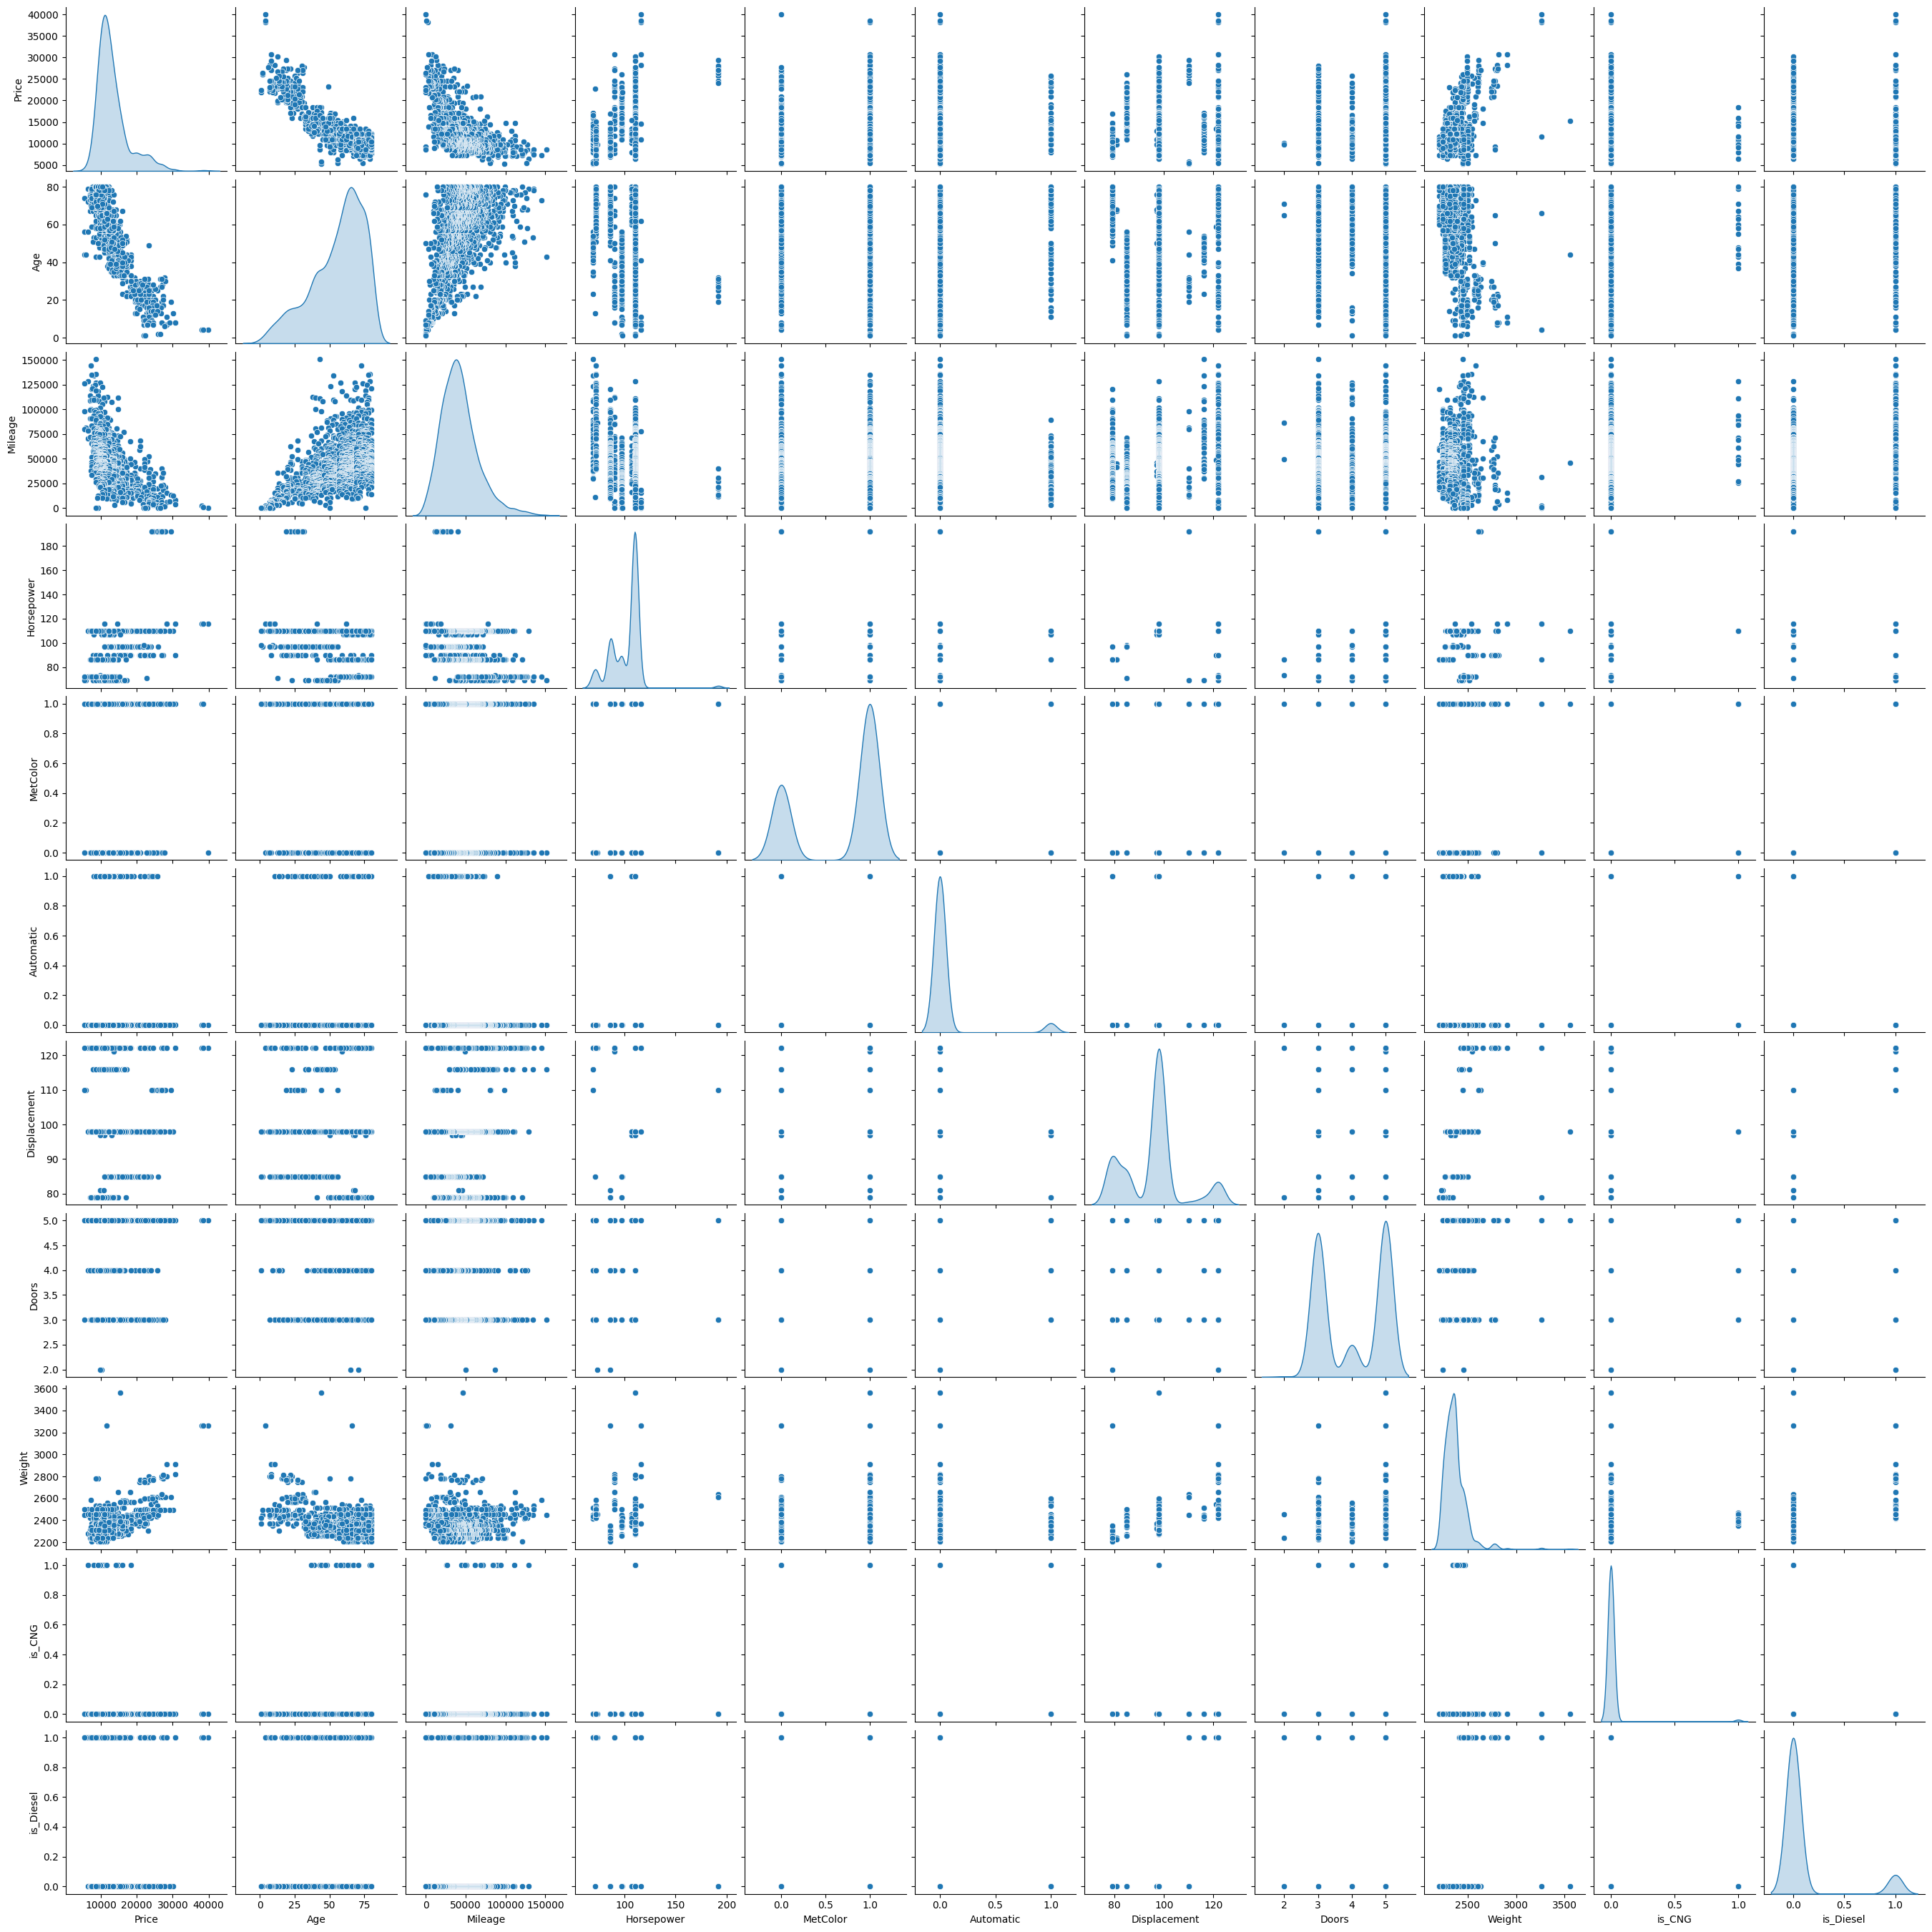

In [113]:
# Pairplot
cols_to_plot = ['Price', 'Age', 'Mileage', 'Horsepower', 'MetColor', 'Automatic', 'Displacement', 'Doors', 'Weight', 'is_CNG', 'is_Diesel']
sns.pairplot(df_4[cols_to_plot], diag_kind='kde')
plt.show()

In [115]:
y_4 = df_4['Mileage']
X_4 = df_4.drop(columns=['Mileage', 'FuelType'])

# Add a constant for the intercept
X_4 = sm.add_constant(X_4)

# Fit the OLS model
model_4 = sm.OLS(y_4, X_4).fit()

# Display the summary to
print(model_4.summary())

                            OLS Regression Results                            
Dep. Variable:                Mileage   R-squared:                       0.550
Model:                            OLS   Adj. R-squared:                  0.547
Method:                 Least Squares   F-statistic:                     174.5
Date:                Sat, 21 Feb 2026   Prob (F-statistic):          3.90e-239
Time:                        00:38:01   Log-Likelihood:                -15904.
No. Observations:                1436   AIC:                         3.183e+04
Df Residuals:                    1425   BIC:                         3.189e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         1.519e+04   1.44e+04      1.053   

In [116]:
y_4 = df_4['Price']
X_4 = df_4['Age']

# Add a constant for the intercept
X_4 = sm.add_constant(X_4)

# Fit the OLS model
model_4 = sm.OLS(y_4, X_4).fit()

# Display the summary to
print(model_4.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.768
Model:                            OLS   Adj. R-squared:                  0.768
Method:                 Least Squares   F-statistic:                     4758.
Date:                Sat, 21 Feb 2026   Prob (F-statistic):               0.00
Time:                        00:42:07   Log-Likelihood:                -13054.
No. Observations:                1436   AIC:                         2.611e+04
Df Residuals:                    1434   BIC:                         2.612e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.496e+04    179.699    138.910      0.0

In [119]:

new_data = pd.DataFrame({
    'const': [1],  # Constant term for the intercept
    'Age': [48],
})

# Predict
predicted_res = model_4.predict(new_data)[0]

print(f"Predicted Result: {predicted_res:.2f}")

# standerd deviation
rmse = np.sqrt(model_4.mse_resid)
print(f"RMSE: {rmse:f}")
print(f"95%: ({(predicted_res - rmse * 2):.2f}, {(predicted_res + rmse * 2):.2f})")



Predicted Result: 14870.12
RMSE: 2147.624740
95%: (10574.87, 19165.37)


In [120]:
y_4 = df_4['Price']
X_4 = df_4.drop(columns=['Price', 'FuelType'])

# Add a constant for the intercept
X_4 = sm.add_constant(X_4)

# Fit the OLS model
model_4 = sm.OLS(y_4, X_4).fit()

# Display the summary to
print(model_4.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.869
Model:                            OLS   Adj. R-squared:                  0.868
Method:                 Least Squares   F-statistic:                     947.1
Date:                Sat, 21 Feb 2026   Prob (F-statistic):               0.00
Time:                        00:50:53   Log-Likelihood:                -12643.
No. Observations:                1436   AIC:                         2.531e+04
Df Residuals:                    1425   BIC:                         2.537e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const        -3671.9544   1487.015     -2.469   

In [121]:

new_data = pd.DataFrame({
    'const': [1],  # Constant term for the intercept
    'Age': [48],
    'Mileage': [45000],
    'Horsepower': [90],
    'MetColor': [0],
    'Automatic': [1],
    'Displacement': [122],
    'Doors': [4],
    'Weight': [2568],
    'is_CNG': [0],
    'is_Diesel': [1]
})

# Predict
predicted_res = model_4.predict(new_data)[0]

print(f"Predicted Result: {predicted_res:.2f}")

# standerd deviation
rmse = np.sqrt(model_4.mse_resid)
print(f"RMSE: {rmse:f}")
print(f"95%: ({(predicted_res - rmse * 2):.2f}, {(predicted_res + rmse * 2):.2f})")



Predicted Result: 16348.12
RMSE: 1618.986411
95%: (13110.15, 19586.09)


In [124]:
''' part 5 '''
df_5 = pd.read_csv('Boston-1.csv')
df_5.head()

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [127]:
X_5 = df_5.drop(columns=['crim', 'Unnamed: 0'])
y_5 = df_5['crim']
columns = X_5.columns.to_list()
X_5 = sm.add_constant(X_5)
columns

['zn',
 'indus',
 'chas',
 'nox',
 'rm',
 'age',
 'dis',
 'rad',
 'tax',
 'ptratio',
 'black',
 'lstat',
 'medv']

In [143]:
models_5 = []
for col in columns:
  model_5 = sm.OLS(y_5, X_5[['const', col]]).fit()
  models_5.append(model_5)
  print(model_5.summary())

                            OLS Regression Results                            
Dep. Variable:                   crim   R-squared:                       0.040
Model:                            OLS   Adj. R-squared:                  0.038
Method:                 Least Squares   F-statistic:                     21.10
Date:                Sat, 21 Feb 2026   Prob (F-statistic):           5.51e-06
Time:                        02:53:56   Log-Likelihood:                -1796.0
No. Observations:                 506   AIC:                             3596.
Df Residuals:                     504   BIC:                             3604.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.4537      0.417     10.675      0.0

/tmp/ipython-input-2178518106.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(data=df_results, x='R_Squared', y='Predictor', palette='Blues_r')


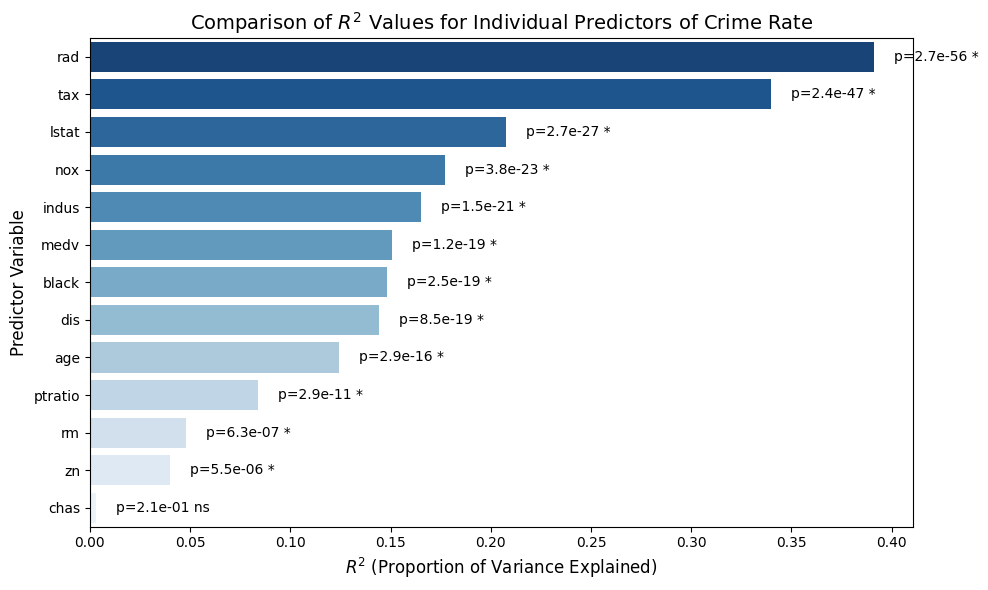

In [144]:
# 1. Collect the results into a list of dictionaries
results_list = []
for index in range(len(models_5)):
    results_list.append({
        'Predictor': columns[index],
        'R_Squared': models_5[index].rsquared,
        'P_Value': models_5[index].f_pvalue
    })

# 2. Create a DataFrame and sort by R-squared
df_results = pd.DataFrame(results_list).sort_values(by='R_Squared', ascending=False)

# 3. Create the bar plot
plt.figure(figsize=(10, 6))
plot = sns.barplot(data=df_results, x='R_Squared', y='Predictor', palette='Blues_r')

# 4. Add labels and title
plt.title('Comparison of $R^2$ Values for Individual Predictors of Crime Rate', fontsize=14)
plt.xlabel('$R^2$ (Proportion of Variance Explained)', fontsize=12)
plt.ylabel('Predictor Variable', fontsize=12)

# 5. Optional: Add P-value labels to the bars
for i, row in enumerate(df_results.itertuples()):
    # Show "sig" if p-value < 0.05
    sig_label = "*" if row.P_Value < 0.05 else "ns"
    plt.text(row.R_Squared + 0.01, i, f'p={row.P_Value:.1e} {sig_label}', va='center')

plt.tight_layout()
plt.show()

In [145]:
model_5 = sm.OLS(y_5, X_5).fit()
print(model_5.summary())

                            OLS Regression Results                            
Dep. Variable:                   crim   R-squared:                       0.454
Model:                            OLS   Adj. R-squared:                  0.440
Method:                 Least Squares   F-statistic:                     31.47
Date:                Sat, 21 Feb 2026   Prob (F-statistic):           1.57e-56
Time:                        02:56:23   Log-Likelihood:                -1653.3
No. Observations:                 506   AIC:                             3335.
Df Residuals:                     492   BIC:                             3394.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         17.0332      7.235      2.354      0.0

/tmp/ipython-input-761223347.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  univariate_coefs = [m.params[1] for m in models_5]
/tmp/ipython-input-761223347.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate(txt, (univariate_coefs[i], multiple_coefs[i]),


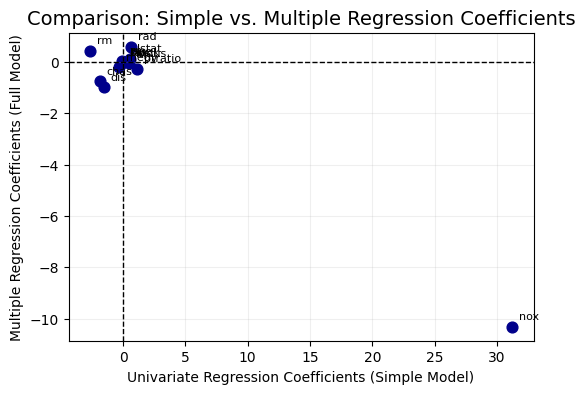

In [156]:
univariate_coefs = [m.params[1] for m in models_5]
multiple_coefs = model_2.params.drop('const')
plt.figure(figsize=(6, 4))
plt.scatter(univariate_coefs, multiple_coefs, color='darkblue', s=60)

for i, txt in enumerate(columns):
    plt.annotate(txt, (univariate_coefs[i], multiple_coefs[i]),
                 xytext=(5, 5), textcoords='offset points', fontsize=8)

plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Univariate Regression Coefficients (Simple Model)', fontsize=10)
plt.ylabel('Multiple Regression Coefficients (Full Model)', fontsize=10)
plt.title('Comparison: Simple vs. Multiple Regression Coefficients', fontsize=14)
plt.grid(alpha=0.2)

plt.show()

In [167]:
models_5_non_linear = []
y_5 = df_5['crim']
for col in columns:
  X_5_non_linear = X_5[['const', col]].copy()
  X_5_non_linear[col + '2'] = X_5[col] ** 2
  X_5_non_linear[col + '3'] = X_5[col] ** 3

  model_5_non_linear = sm.OLS(y_5, X_5_non_linear).fit()
  models_5_non_linear.append(model_5_non_linear)
  print(model_5_non_linear.summary())

                            OLS Regression Results                            
Dep. Variable:                   crim   R-squared:                       0.058
Model:                            OLS   Adj. R-squared:                  0.053
Method:                 Least Squares   F-statistic:                     10.35
Date:                Sat, 21 Feb 2026   Prob (F-statistic):           1.28e-06
Time:                        03:14:55   Log-Likelihood:                -1791.2
No. Observations:                 506   AIC:                             3590.
Df Residuals:                     502   BIC:                             3607.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.8461      0.433     11.192      0.0

/tmp/ipython-input-2906182694.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(data=df_results, x='R_Squared', y='Predictor', palette='Blues_r')


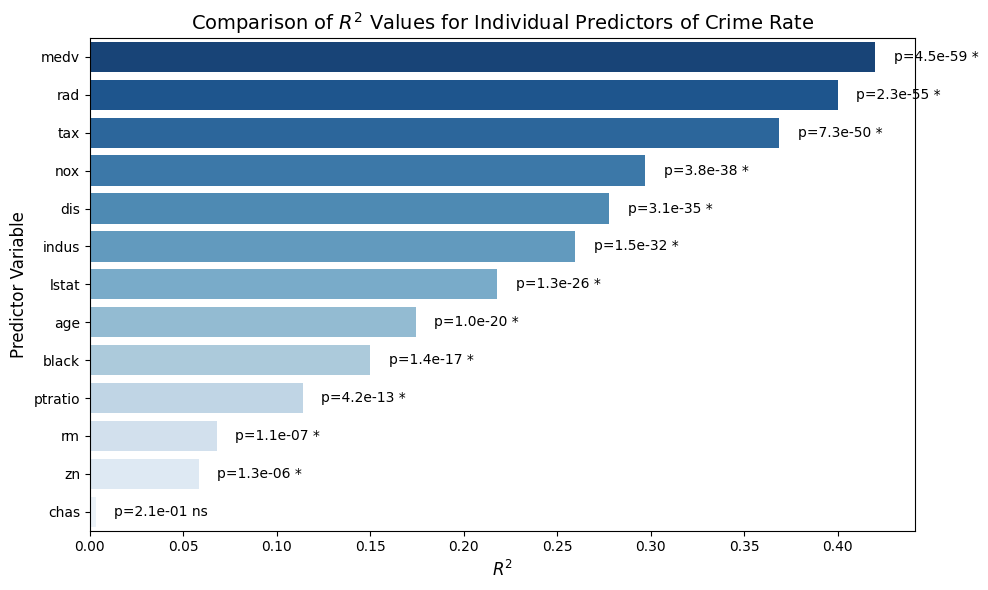

In [168]:

results_list = []
for index in range(len(models_5_non_linear)):
    results_list.append({
        'Predictor': columns[index],
        'R_Squared': models_5_non_linear[index].rsquared,
        'P_Value': models_5_non_linear[index].f_pvalue
    })

# 2. Create a DataFrame and sort by R-squared
df_results = pd.DataFrame(results_list).sort_values(by='R_Squared', ascending=False)

# 3. Create the bar plot
plt.figure(figsize=(10, 6))
plot = sns.barplot(data=df_results, x='R_Squared', y='Predictor', palette='Blues_r')

# 4. Add labels and title
plt.title('Comparison of $R^2$ Values for Individual Predictors of Crime Rate', fontsize=14)
plt.xlabel('$R^2$', fontsize=12)
plt.ylabel('Predictor Variable', fontsize=12)

# 5. Optional: Add P-value labels to the bars
for i, row in enumerate(df_results.itertuples()):
    # Show "sig" if p-value < 0.05
    sig_label = "*" if row.P_Value < 0.05 else "ns"
    plt.text(row.R_Squared + 0.01, i, f'p={row.P_Value:.1e} {sig_label}', va='center')

plt.tight_layout()
plt.show()